In [8]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
texts = [
    "I love this product",
    "The service is excellent",
    "Amazing product and great quality",
    "I am very happy",
    "I highly recommend this",
    "The product is wonderful",
    "I hate this product",
    "The service is terrible",
    "Very bad quality",
    "I am unhappy",
    "I do not recommend this",
    "The product is disappointing"
]

labels = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print(df)

                                 text  label
0                 I love this product      1
1            The service is excellent      1
2   Amazing product and great quality      1
3                     I am very happy      1
4             I highly recommend this      1
5            The product is wonderful      1
6                 I hate this product      0
7             The service is terrible      0
8                    Very bad quality      0
9                        I am unhappy      0
10            I do not recommend this      0
11       The product is disappointing      0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9
Testing samples: 3


In [10]:
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train).toarray()
X_test = vectorizer.transform(X_test).toarray()

y_train = np.array(y_train)
y_test = np.array(y_test)

print("TF-IDF completed")
print("Number of features:", X_train.shape[1])

TF-IDF completed
Number of features: 19


In [11]:
class TextClassifier(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


model = TextClassifier(X_train.shape[1])

print(model)

TextClassifier(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=32, out_features=1, bias=True)
    (8): Sigmoid()
  )
)


In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

for epoch in range(50):

    model.train()

    optimizer.zero_grad()

    output = model(X_train_tensor)

    loss = criterion(
        output,
        y_train_tensor
    )

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Training completed!")

Training completed!


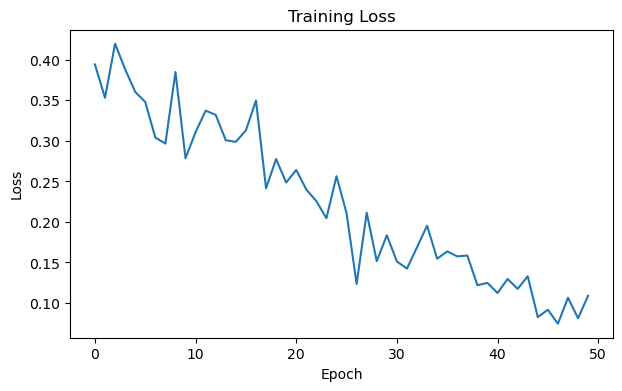

In [14]:
plt.figure(figsize=(7, 4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [15]:
model.eval()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

with torch.no_grad():

    probabilities = model(
        X_test_tensor
    ).numpy().flatten()

predictions = (
    probabilities >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Test Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=["Negative", "Positive"]
    )
)

Test Accuracy: 33.33 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



C:\Users\Kasturi S\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kasturi S\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kasturi S\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Confusion Matrix:
[[0 2]
 [0 1]]


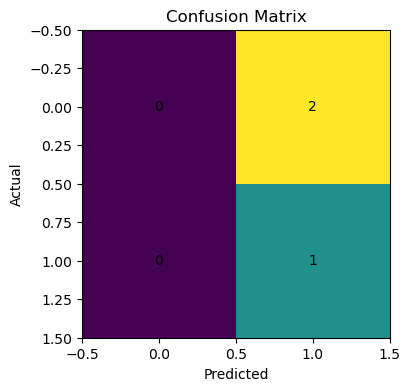

In [16]:
cm = confusion_matrix(
    y_test,
    predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [17]:
new_text = [
    "This product is amazing",
    "This service is very bad"
]

new_data = vectorizer.transform(
    new_text
).toarray()

new_tensor = torch.tensor(
    new_data,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():
    probs = model(new_tensor).numpy().flatten()

for text, prob in zip(new_text, probs):

    if prob >= 0.5:
        result = "Positive"
        confidence = prob * 100
    else:
        result = "Negative"
        confidence = (1 - prob) * 100

    print("\nText:", text)
    print("Prediction:", result)
    print("Confidence:", round(confidence, 2), "%")

torch.save(
    model.state_dict(),
    "task5_text_classifier.pth"
)

print("\nModel saved as task5_text_classifier.pth")


Text: This product is amazing
Prediction: Positive
Confidence: 84.55 %

Text: This service is very bad
Prediction: Negative
Confidence: 85.14 %

Model saved as task5_text_classifier.pth


In [7]:
import torch
print(torch.__version__)

2.14.1+cpu
